# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayla Poetri Kurnia
- **Email:** cdcc200d6x2356@student.devacademy.id
- **ID Dicoding:** CDCC200D6X2356

## Latar Belakang
Penyewaan sepeda dipengaruhi oleh berbagai faktor eksternal seperti kondisi cuaca dan musim.

Memahami pola ini penting untuk meningkatkan efisiensi operasional dan mendukung pengambilan keputusan berbasis data.

## Pertanyaan Bisnis

Analisis ini difokuskan pada periode tahun 2011–2012 sesuai dengan cakupan dataset, dengan tujuan untuk memahami pola dan faktor yang memengaruhi jumlah penyewaan sepeda.

1. Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

2. Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

3. Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

## Import Semua Packages/Library yang Digunakan

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

sns.set(style="whitegrid")

## Data Wrangling

Tahap ini dilakukan untuk memahami kondisi awal dataset serta memastikan data siap digunakan untuk proses analisis. 

### Data Assessing

Pada tahap ini dilakukan pemeriksaan terhadap struktur data, tipe data, missing values, serta duplikasi untuk mengetahui kondisi awal dataset.

In [8]:
df = pd.read_csv("dashboard/data_day.csv")

df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   instant        731 non-null    int64  
 1   dteday         731 non-null    object 
 2   season         731 non-null    object 
 3   yr             731 non-null    int64  
 4   mnth           731 non-null    int64  
 5   holiday        731 non-null    int64  
 6   weekday        731 non-null    int64  
 7   workingday     731 non-null    int64  
 8   weathersit     731 non-null    object 
 9   temp           731 non-null    float64
 10  atemp          731 non-null    float64
 11  hum            731 non-null    float64
 12  windspeed      731 non-null    float64
 13  casual         731 non-null    int64  
 14  registered     731 non-null    int64  
 15  cnt            731 non-null    int64  
 16  kategori_sewa  731 non-null    object 
 17  temp_group     731 non-null    object 
dtypes: float64

np.int64(0)

Dataset terdiri dari 731 observasi tanpa missing values dan duplikasi, sehingga tidak diperlukan proses data cleaning tambahan. Struktur data sudah konsisten, dengan kombinasi variabel numerik dan kategorikal yang memadai untuk analisis eksploratif maupun pemodelan. Namun, variabel waktu (dteday) perlu dikonversi ke tipe datetime agar dapat dimanfaatkan dalam analisis tren dan pola temporal.

### Data Cleaning

Pada tahap ini dilakukan transformasi data untuk meningkatkan keterbacaan dan kemudahan analisis.

In [9]:
# Ubah kolom tanggal
df["dteday"] = pd.to_datetime(df["dteday"])

# Mapping kategori
if df["season"].dtype != "object":
    season_map = {
        1: "Spring",
        2: "Summer",
        3: "Fall",
        4: "Winter"
    }
    df["season"] = df["season"].map(season_map)

if df["weathersit"].dtype != "object":
    weather_map = {
        1: "Clear",
        2: "Mist",
        3: "Light Rain/Snow",
        4: "Heavy Rain/Snow"
    }
    df["weathersit"] = df["weathersit"].map(weather_map)

Dataset telah dibersihkan dan ditransformasikan sehingga siap untuk analisis lanjutan. Konversi tipe data dan pelabelan variabel kategorikal meningkatkan interpretabilitas serta memungkinkan eksplorasi pola temporal dan hubungan antar variabel secara lebih efektif.

## Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk mengeksplorasi data guna memahami karakteristik, distribusi, serta hubungan antar variabel sebelum dilakukan analisis lebih lanjut.

### Univariate Analysis

Analisis univariate dilakukan untuk memahami distribusi masing-masing variabel numerik dalam dataset.

#### Distribusi Jumlah Penyewaan Sepeda (cnt)

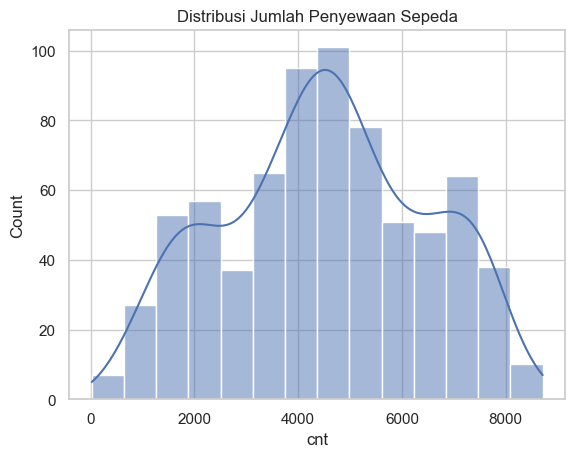

In [5]:
sns.histplot(df["cnt"], kde=True)
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.show()

Distribusi `cnt` cenderung mendekati normal dengan sedikit skew ke kanan, menunjukkan mayoritas hari berada pada tingkat penyewaan menengah, dengan beberapa lonjakan tinggi yang dipengaruhi oleh faktor eksternal seperti cuaca dan musim.

#### Distribusi Temperatur (temp)

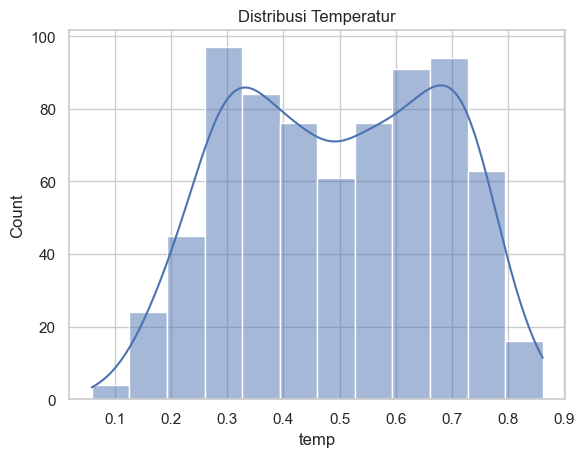

In [6]:
sns.histplot(df["temp"], kde=True)
plt.title("Distribusi Temperatur")
plt.show()

Distribusi `temp` relatif merata dan mendekati normal, menunjukkan variasi suhu yang cukup luas tanpa dominasi ekstrem. Hal ini mengindikasikan bahwa temperatur berpotensi menjadi faktor penting dalam mempengaruhi jumlah penyewaan sepeda.

#### Distribusi Kelembapan (hum)

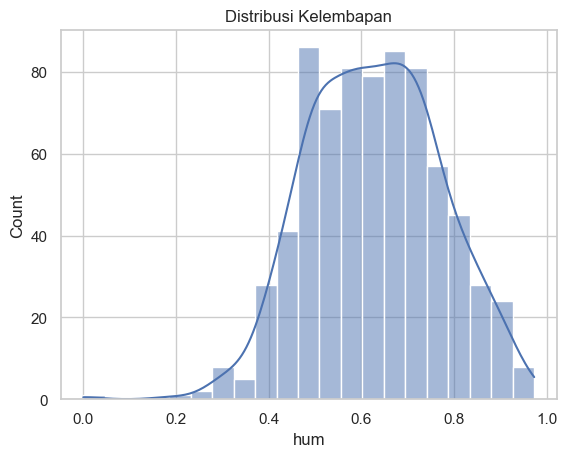

In [7]:
sns.histplot(df["hum"], kde=True)
plt.title("Distribusi Kelembapan")
plt.show()

Distribusi `hum` terkonsentrasi pada nilai menengah hingga tinggi dengan sedikit skew ke kanan, menunjukkan dominasi kondisi kelembapan tinggi yang berpotensi mempengaruhi tingkat penyewaan sepeda.

#### Distribusi Kecepatan Angin (windspeed)

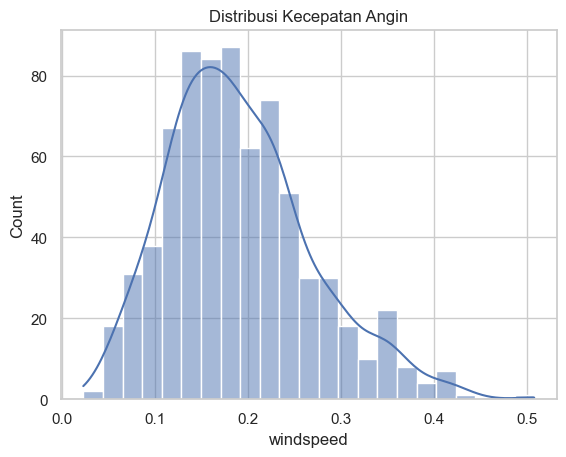

In [8]:
sns.histplot(df["windspeed"], kde=True)
plt.title("Distribusi Kecepatan Angin")
plt.show()

Distribusi `windspeed` cenderung right-skewed, menunjukkan dominasi kecepatan angin rendah hingga sedang, dengan sedikit nilai ekstrem. Kondisi ini berpotensi mempengaruhi tingkat kenyamanan dan jumlah penyewaan sepeda.

#### Boxplot Variabel Numerik

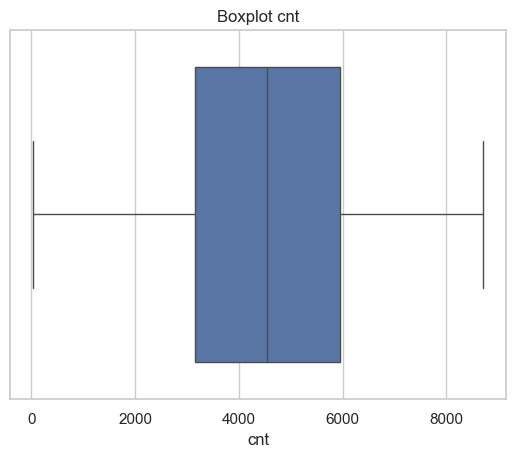

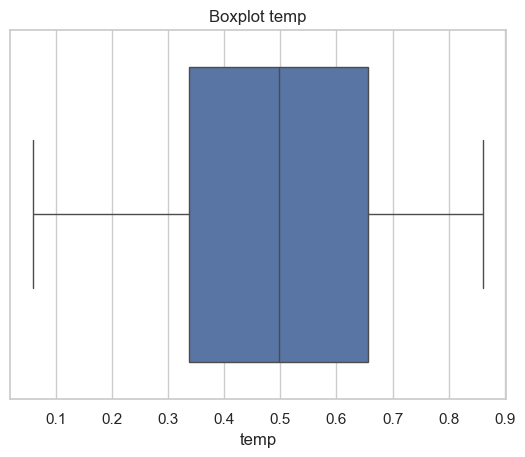

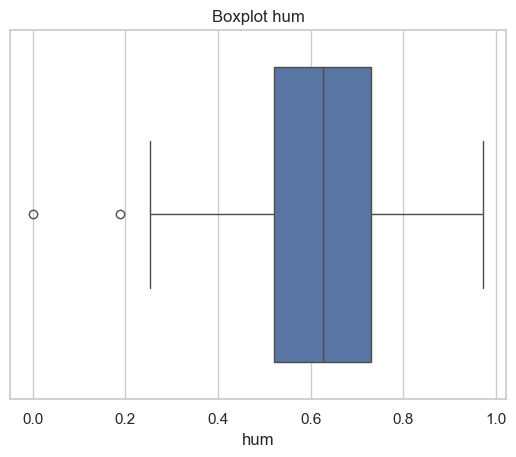

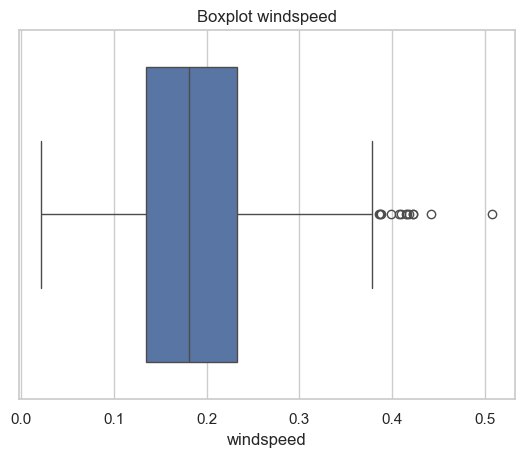

In [9]:
num_cols = ["cnt","temp","hum","windspeed"]

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

Variabel `cnt` memiliki variabilitas tertinggi, menunjukkan fluktuasi permintaan yang dipengaruhi banyak faktor. Sementara itu, `temp` relatif stabil, sedangkan `hum` dan `windspeed` memiliki beberapa outlier yang dapat merepresentasikan kondisi ekstrem dan berpotensi mempengaruhi jumlah penyewaan.

### Skewness dan Kurtosis

In [10]:
for col in num_cols:
    print(col)
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())
    print("------")

cnt
Skewness: -0.04735278011900183
Kurtosis: -0.8119223847191548
------
temp
Skewness: -0.054520964760408276
Kurtosis: -1.1188641545735662
------
hum
Skewness: -0.06978343399095213
Kurtosis: -0.06453013469388669
------
windspeed
Skewness: 0.6773454211095378
Kurtosis: 0.4109222677315354
------


Sebagian besar variabel memiliki distribusi simetris (skewness ≈ 0) dengan penyebaran yang relatif merata, menunjukkan data yang stabil. Namun, `windspeed` cenderung right-skewed dengan indikasi nilai ekstrem, yang perlu diperhatikan karena berpotensi mempengaruhi pola penyewaan sepeda.

#### Q-Q Plot Distribusi (cnt)

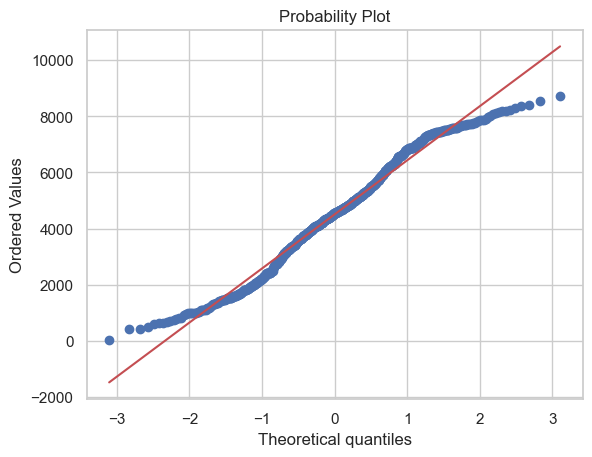

In [11]:
stats.probplot(df["cnt"], dist="norm", plot=plt)
plt.show()

Q-Q plot menunjukkan bahwa distribusi `cnt` mendekati normal, meskipun terdapat deviasi pada bagian ekor yang mengindikasikan adanya nilai ekstrem. Hal ini masih wajar dalam data real-world dan tidak memerlukan transformasi signifikan pada tahap eksplorasi.

### Multivariate Analysis

Analisis ini dilakukan untuk memahami hubungan antar variabel numerik dalam dataset.

#### Correlation Matrix antar Variabel Numerik

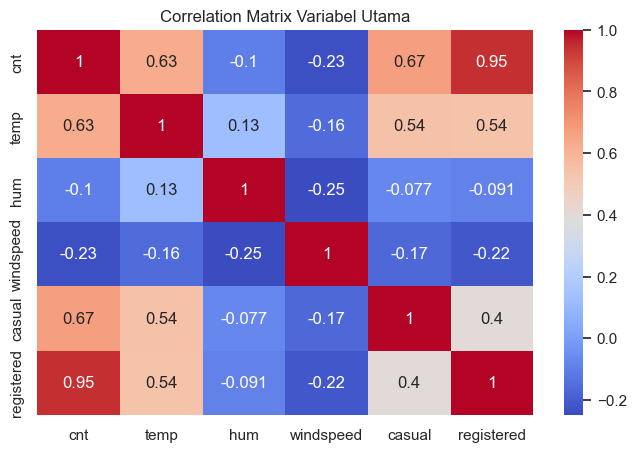

In [10]:
cols = ["cnt","temp","hum","windspeed","casual","registered"]

plt.figure(figsize=(8,5))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Variabel Utama")
plt.show()

Correlation matrix menunjukkan bahwa `registered` merupakan faktor paling dominan dalam menentukan `cnt`, diikuti oleh `casual`. Hal ini menunjukkan bahwa jumlah pengguna terdaftar memiliki kontribusi terbesar terhadap total penyewaan.

Variabel `temp` menunjukkan korelasi positif moderat terhadap `cnt`, yang mengindikasikan bahwa peningkatan temperatur cenderung meningkatkan jumlah penyewaan sepeda. Sebaliknya, `hum` dan `windspeed` memiliki korelasi negatif lemah, yang menunjukkan bahwa kondisi kelembapan tinggi dan angin kencang cenderung menurunkan jumlah penyewaan, meskipun pengaruhnya tidak signifikan.

Text(0.5, 1.0, 'Hubungan Temperatur dan Penyewaan')

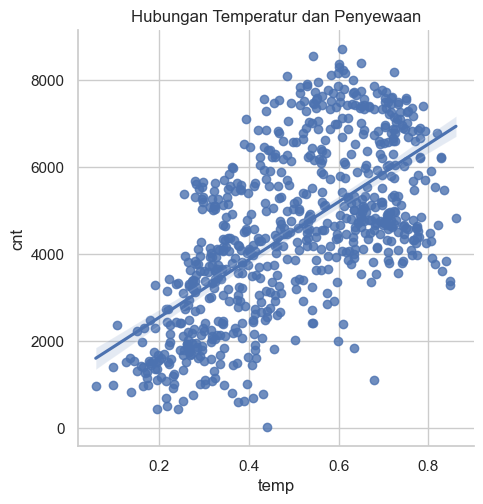

In [13]:
# Scatter Tempt vs Cnt
sns.lmplot(x="temp", y="cnt", data=df)
plt.title("Hubungan Temperatur dan Penyewaan")

Scatter plot menunjukkan hubungan positif antara `temp` dan `cnt`, di mana peningkatan temperatur cenderung diikuti oleh peningkatan jumlah penyewaan sepeda.

Pola titik yang membentuk tren naik serta garis regresi yang positif memperkuat hasil correlation sebelumnya. Meskipun terdapat variasi data pada setiap tingkat temperatur, tren umum tetap konsisten, yang mengindikasikan bahwa temperatur merupakan salah satu faktor penting dalam memengaruhi permintaan penyewaan sepeda.

Text(0.5, 1.0, 'Hubungan Kelembapan dan Penyewaan')

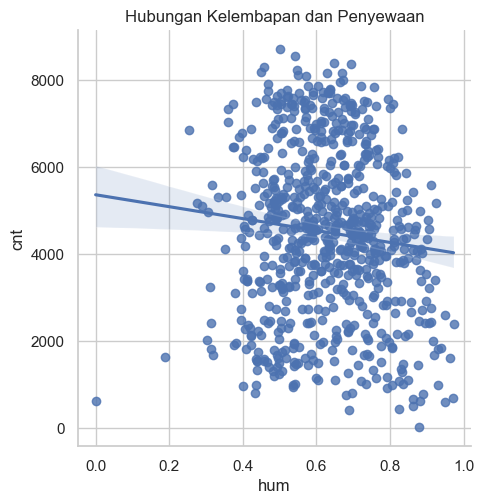

In [12]:
# Scatter Hum vs Cnt
sns.lmplot(x="hum", y="cnt", data=df)
plt.title("Hubungan Kelembapan dan Penyewaan")

Scatter plot menunjukkan bahwa `hum` memiliki hubungan negatif yang lemah terhadap `cnt`, di mana peningkatan kelembapan cenderung diikuti oleh sedikit penurunan jumlah penyewaan sepeda.

Namun, penyebaran titik yang cukup luas menunjukkan bahwa hubungan ini tidak terlalu kuat dan dipengaruhi oleh faktor lain. Hal ini mengindikasikan bahwa kelembapan bukan merupakan faktor utama dalam menentukan jumlah penyewaan.

Text(0.5, 1.0, 'Hubungan Kecepatan Angin dan Penyewaan')

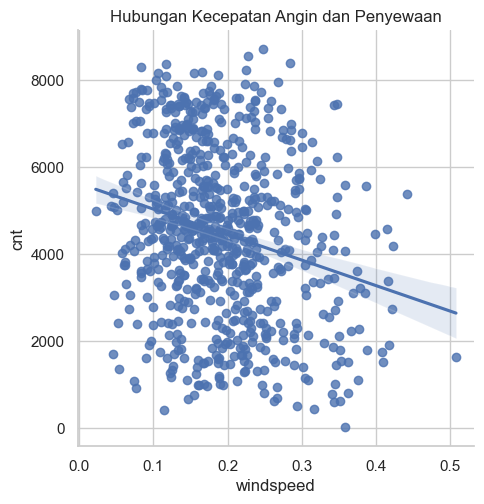

In [13]:
# Scatter Windspeed vs Cnt
sns.lmplot(x="windspeed", y="cnt", data=df)
plt.title("Hubungan Kecepatan Angin dan Penyewaan")

Scatter plot menunjukkan bahwa `windspeed` memiliki hubungan negatif yang lemah terhadap `cnt`, di mana peningkatan kecepatan angin cenderung diikuti oleh penurunan jumlah penyewaan sepeda.

Namun, penyebaran titik yang cukup luas menunjukkan bahwa hubungan ini tidak kuat, sehingga `windspeed` bukan merupakan faktor utama dalam memengaruhi jumlah penyewaan.

Secara keseluruhan, temperatur merupakan faktor yang paling berpengaruh terhadap jumlah penyewaan sepeda, dengan hubungan positif yang cukup kuat. Sementara itu, kelembapan dan kecepatan angin menunjukkan hubungan negatif yang lemah, sehingga pengaruhnya relatif kecil dibandingkan temperatur.

### Numerical Analysis

Analisis ini dilakukan untuk memahami distribusi statistik data secara lebih mendalam.

In [35]:
# Percentile
df["cnt"].describe(percentiles=[0.05,0.1,0.9,0.95])

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
5%       1331.000000
10%      1746.000000
50%      4548.000000
90%      7290.000000
95%      7576.000000
max      8714.000000
Name: cnt, dtype: float64

Distribusi `cnt` menunjukkan bahwa nilai mean (≈4504) dan median (≈4548) relatif berdekatan, yang mengindikasikan distribusi cukup simetris.

Rentang antara persentil 10% hingga 90% (≈1746–7290) menunjukkan variasi jumlah penyewaan yang cukup besar antar hari. Hal ini diperkuat oleh nilai standar deviasi yang tinggi (~1937), yang menandakan adanya fluktuasi permintaan yang signifikan.

Dengan demikian, meskipun distribusi cenderung stabil secara umum, jumlah penyewaan tetap dipengaruhi oleh faktor eksternal yang menyebabkan variasi harian.

In [36]:
# Standard Deviation
df.groupby("season")["cnt"].std()
df.groupby("weathersit")["cnt"].std()

weathersit
Clear              1879.483989
Light Rain/Snow    1240.284449
Mist               1809.109918
Name: cnt, dtype: float64

Standar deviasi menunjukkan bahwa variasi jumlah penyewaan paling tinggi terjadi pada kondisi cuaca cerah (~1879) dan berkabut (~1809), sedangkan pada kondisi hujan ringan lebih rendah (~1240).

Hal ini mengindikasikan bahwa pada cuaca baik, permintaan tidak hanya lebih tinggi tetapi juga lebih fluktuatif, kemungkinan dipengaruhi oleh aktivitas pengguna yang lebih dinamis. Sebaliknya, saat hujan ringan, jumlah penyewaan cenderung lebih stabil namun berada pada tingkat yang lebih rendah.

Dengan demikian, kondisi cuaca tidak hanya memengaruhi tingkat penyewaan, tetapi juga tingkat variabilitas permintaan.

### Categorical Analysis

Analisis ini dilakukan untuk melihat perbedaan distribusi jumlah penyewaan berdasarkan kategori.

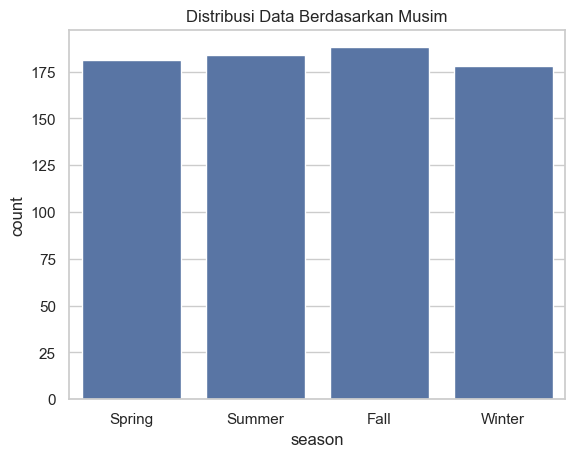

In [14]:
# Countplot Season
sns.countplot(x="season", data=df)
plt.title("Distribusi Data Berdasarkan Musim")
plt.show()

Distribusi data antar musim relatif seimbang, menunjukkan bahwa dataset tidak bias terhadap musim tertentu. Hal ini penting karena analisis selanjutnya dapat dilakukan tanpa khawatir adanya ketidakseimbangan jumlah data pada tiap kategori musim.

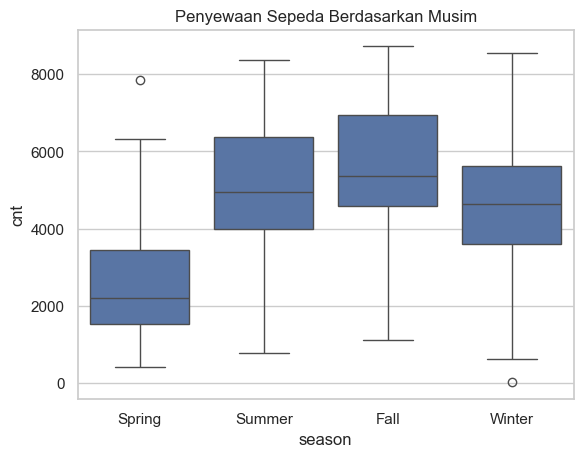

In [15]:
# Boxplot Season vs Cnt
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Penyewaan Sepeda Berdasarkan Musim")
plt.show()

Distribusi jumlah penyewaan menunjukkan bahwa musim Fall dan Summer memiliki median penyewaan yang lebih tinggi dibandingkan musim lainnya, sementara Spring memiliki median terendah.

Selain itu, variasi (IQR) pada Fall dan Summer juga lebih besar, yang mengindikasikan fluktuasi permintaan yang lebih tinggi pada musim tersebut. Hal ini menunjukkan bahwa kondisi cuaca yang lebih hangat cenderung meningkatkan aktivitas penyewaan sepeda.

Sebaliknya, pada musim Spring dan Winter, jumlah penyewaan relatif lebih rendah dan kurang bervariasi.

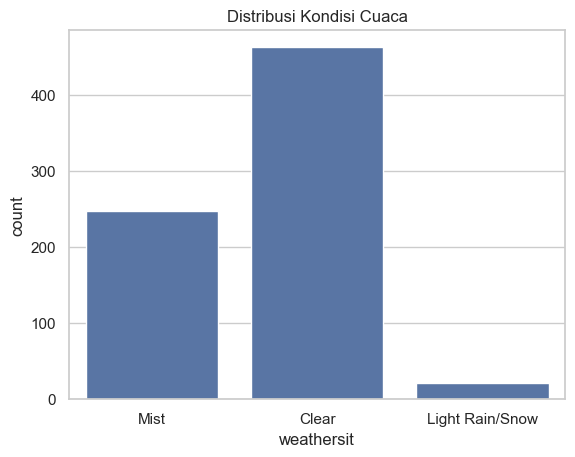

In [16]:
# Countplot Weather
sns.countplot(x="weathersit", data=df)
plt.title("Distribusi Kondisi Cuaca")
plt.show()

Distribusi kondisi cuaca tidak seimbang, dengan mayoritas data berada pada kondisi cerah, diikuti oleh berkabut, dan sangat sedikit pada kondisi hujan ringan/salju.

Ketimpangan ini menunjukkan bahwa analisis lebih banyak merepresentasikan kondisi cuaca normal, sehingga insight yang dihasilkan cenderung bias terhadap kondisi cerah. Sementara itu, pola pada kondisi cuaca ekstrem kurang terwakili dan perlu diinterpretasikan dengan hati-hati.

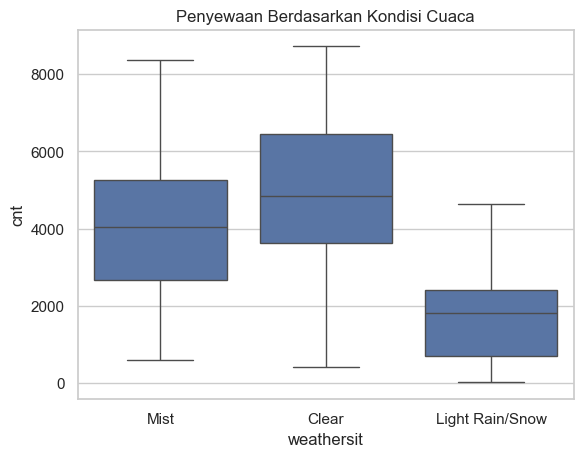

In [17]:
# Boxplot Weather vs Cnt
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Penyewaan Berdasarkan Kondisi Cuaca")
plt.show()

Distribusi jumlah penyewaan menunjukkan bahwa kondisi cuaca cerah memiliki median tertinggi, diikuti oleh berkabut, sementara hujan ringan/salju memiliki median terendah.

Selain itu, variasi penyewaan pada kondisi cerah dan berkabut relatif lebih besar dibandingkan kondisi hujan, yang mengindikasikan bahwa aktivitas penyewaan lebih dinamis saat cuaca baik. Sebaliknya, pada kondisi cuaca buruk, jumlah penyewaan tidak hanya lebih rendah tetapi juga lebih terbatas.

Hal ini menegaskan bahwa kondisi cuaca merupakan faktor penting yang memengaruhi tingkat dan variabilitas permintaan sepeda.

## Analisis Lanjutan (Opsional)

Pada bagian ini dilakukan analisis tambahan untuk menggali insight lebih dalam terkait faktor-faktor yang memengaruhi jumlah penyewaan sepeda.

### Aggregation Analysis

In [20]:
df.groupby("season")["cnt"].agg(["mean","max","min"])

df.groupby("weathersit")["cnt"].agg(["mean","max","min"])

,mean,max,min
weathersit,,,
Clear,4876.786177,8714,431
Light Rain/Snow,1803.285714,4639,22
Mist,4035.862348,8362,605


Hasil agregasi menunjukkan bahwa kondisi cuaca cerah (Clear) memiliki rata-rata penyewaan tertinggi, diikuti oleh kondisi berkabut (Mist), dan terendah pada kondisi hujan ringan/salju (Light Rain/Snow).

Selain itu, perbedaan nilai maksimum dan minimum menunjukkan bahwa kondisi cuaca tidak hanya memengaruhi rata-rata penyewaan, tetapi juga memengaruhi variasi dan ekstremitas permintaan.

Hal ini menegaskan bahwa faktor cuaca memiliki pengaruh signifikan terhadap pola penyewaan sepeda.

### Binning Analysis (Temperatur)

In [23]:
df["temp_category"] = pd.cut(
    df["temp"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [24]:
temp_summary = df.groupby("temp_category", observed=True)["cnt"].mean()
print(temp_summary)

temp_category
Low       2381.214815
Medium    4488.178363
High      5654.559055
Name: cnt, dtype: float64


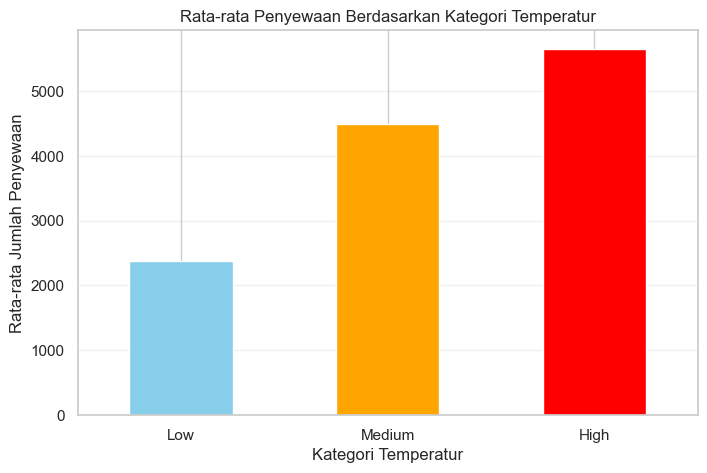

In [25]:
plt.figure(figsize=(8,5))

temp_summary.plot(kind="bar", color=["skyblue", "orange", "red"])

plt.title("Rata-rata Penyewaan Berdasarkan Kategori Temperatur")
plt.xlabel("Kategori Temperatur")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

Semakin tinggi kategori temperatur, semakin tinggi rata-rata penyewaan sepeda. Hal ini menunjukkan bahwa temperatur memiliki pengaruh positif dan signifikan terhadap permintaan.

### Analisis Kombinasi Musim dan Cuaca

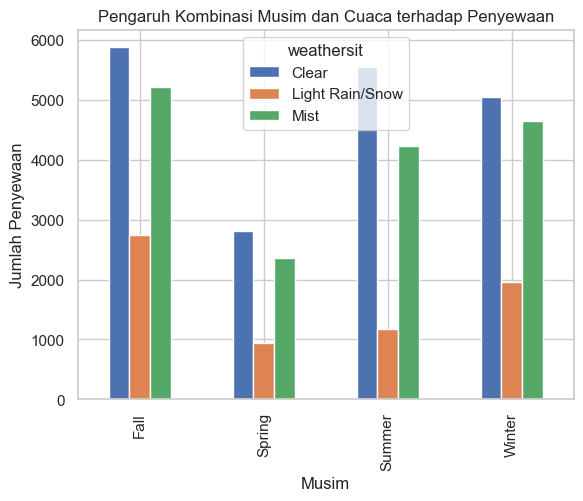

In [26]:
df.groupby(["season","weathersit"])["cnt"].mean().unstack().plot(kind="bar")

plt.title("Pengaruh Kombinasi Musim dan Cuaca terhadap Penyewaan")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

Berdasarkan visualisasi, jumlah penyewaan sepeda dipengaruhi oleh kombinasi antara musim dan kondisi cuaca. Pada kondisi Clear, penyewaan tertinggi terjadi di semua musim, terutama pada Fall dan Summer.

Sebaliknya, pada kondisi Light Rain/Snow, jumlah penyewaan menjadi yang terendah di seluruh musim, menunjukkan bahwa cuaca buruk secara signifikan menurunkan permintaan. Sementara itu, kondisi Mist berada di tingkat menengah.

Hal ini menunjukkan bahwa cuaca merupakan faktor dominan yang dapat memperkuat atau melemahkan pengaruh musim terhadap penyewaan sepeda.

## Analisis Berdasarkan Pertanyaan Bisnis

Pada bagian ini dilakukan analisis lanjutan untuk menjawab pertanyaan bisnis yang telah dirumuskan sebelumnya berdasarkan hasil Exploratory Data Analysis (EDA).

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (temperatur, kelembapan, dan kecepatan angin) terhadap jumlah penyewaan sepeda pada periode 2011–2012?

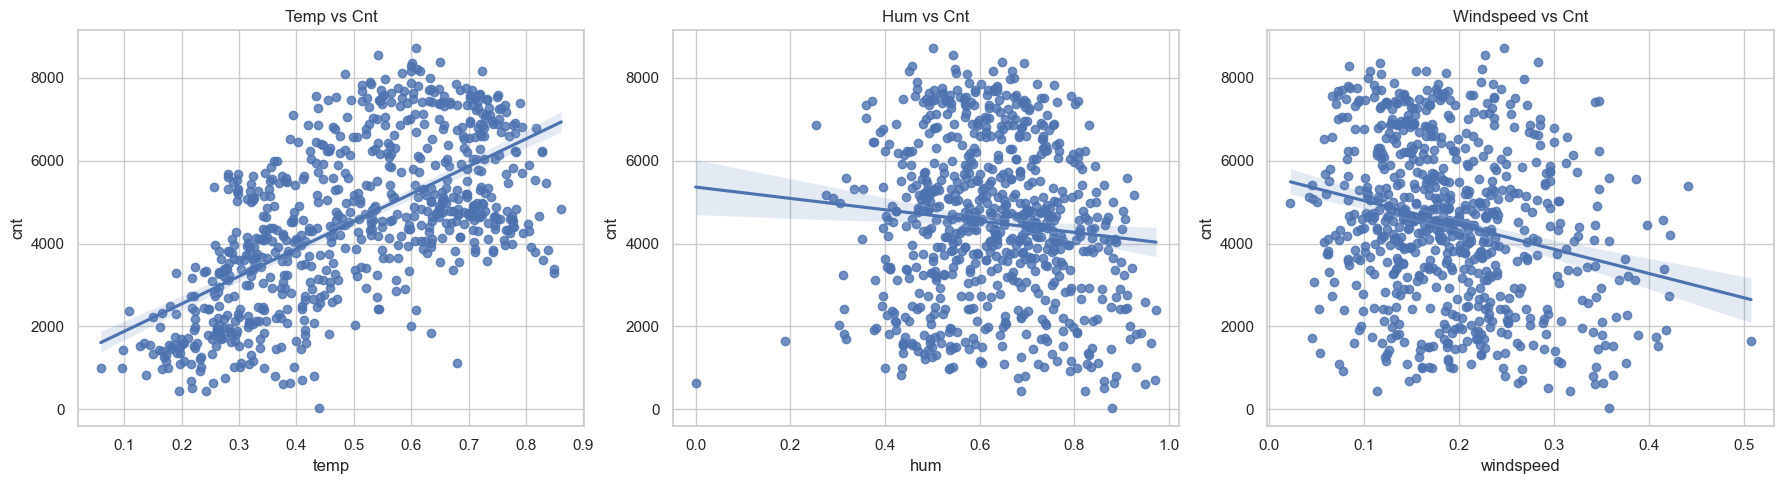

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(x="temp", y="cnt", data=df, ax=axes[0])
axes[0].set_title("Temp vs Cnt")

sns.regplot(x="hum", y="cnt", data=df, ax=axes[1])
axes[1].set_title("Hum vs Cnt")

sns.regplot(x="windspeed", y="cnt", data=df, ax=axes[2])
axes[2].set_title("Windspeed vs Cnt")

plt.tight_layout()
plt.show()

Berdasarkan visualisasi hubungan antara variabel cuaca dan jumlah penyewaan sepeda pada periode **2011–2012**, terlihat bahwa **temperatur** memiliki hubungan **positif yang cukup kuat** terhadap jumlah penyewaan. Hal ini ditunjukkan oleh pola titik yang cenderung meningkat serta **garis tren yang menanjak**, yang mengindikasikan bahwa semakin tinggi temperatur, semakin tinggi jumlah penyewaan sepeda.

Sebaliknya, **kelembapan** menunjukkan hubungan **negatif yang lemah** terhadap jumlah penyewaan. Meskipun terdapat kecenderungan penurunan pada garis tren, **sebaran data yang cukup luas** menunjukkan bahwa pengaruh kelembapan tidak terlalu signifikan dalam menentukan jumlah penyewaan.

**Kecepatan angin** juga menunjukkan hubungan **negatif yang lemah**, dengan pola sebaran data yang relatif acak dan garis tren yang sedikit menurun. Hal ini menunjukkan bahwa peningkatan kecepatan angin cenderung diikuti oleh penurunan jumlah penyewaan, namun pengaruhnya tidak dominan.

Secara keseluruhan, dapat disimpulkan bahwa dari ketiga variabel cuaca yang dianalisis, **temperatur merupakan faktor yang paling berpengaruh** terhadap jumlah penyewaan sepeda, sedangkan **kelembapan** dan **kecepatan angin** hanya memberikan **pengaruh tambahan yang relatif kecil**.

### Pertanyaan 2: Pada musim apa jumlah penyewaan sepeda paling tinggi dan paling rendah selama periode 2011–2012?

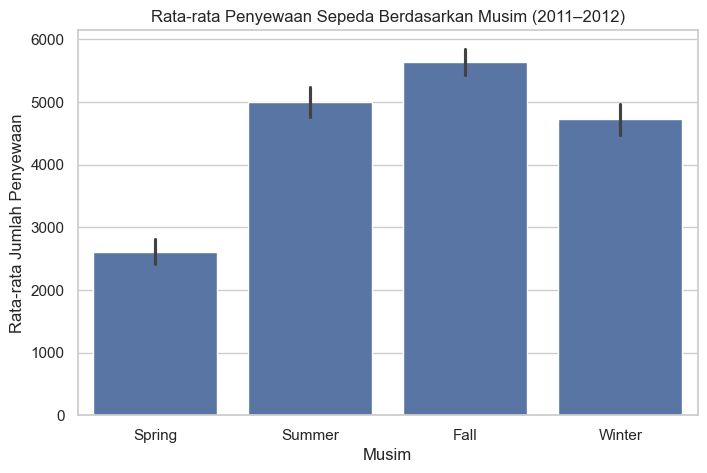

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="season", 
    y="cnt", 
    data=df,
    order=["Spring", "Summer", "Fall", "Winter"],
    estimator=np.mean
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim (2011–2012)")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Jumlah Penyewaan")

plt.show()

Berdasarkan visualisasi, jumlah penyewaan sepeda **tertinggi terjadi pada musim Fall**, diikuti oleh **Summer** dan **Winter**, sedangkan yang **terendah terjadi pada musim Spring** selama periode 2011–2012.

Perbedaan ini menunjukkan adanya variasi jumlah penyewaan yang cukup jelas antar musim.

Hal ini mengindikasikan bahwa faktor musim memiliki pengaruh terhadap tingkat permintaan penyewaan sepeda. Musim dengan kondisi cuaca yang lebih mendukung aktivitas luar ruangan cenderung memiliki jumlah penyewaan yang lebih tinggi.

Oleh karena itu, penyedia layanan dapat menyesuaikan strategi operasional, seperti meningkatkan ketersediaan sepeda pada musim dengan permintaan tinggi dan mengoptimalkan promosi pada musim dengan permintaan rendah.

### Pertanyaan 3: Bagaimana tren perubahan jumlah penyewaan sepeda dari waktu ke waktu dari Januari 2011 hingga Desember 2012?

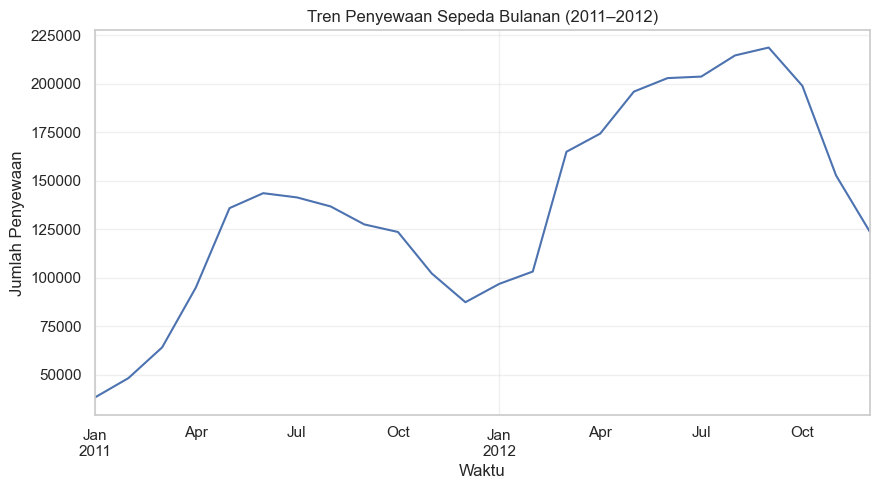

In [19]:
monthly = df.set_index("dteday").resample("ME")["cnt"].sum()

plt.figure(figsize=(10,5))
monthly.plot()

plt.title("Tren Penyewaan Sepeda Bulanan (2011–2012)")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Penyewaan")
plt.grid(alpha=0.3)

plt.show()

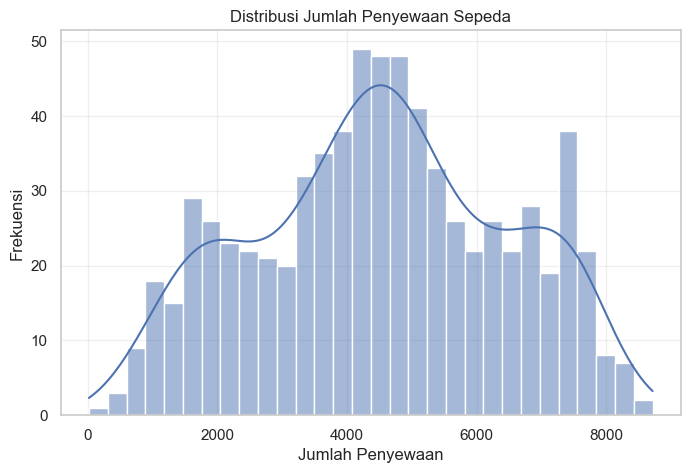

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["cnt"], kde=True, bins=30)

plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.grid(alpha=0.3)

plt.show()

Berdasarkan analisis periode Januari 2011–Desember 2012, terlihat adanya tren peningkatan jumlah penyewaan sepeda dari waktu ke waktu, dengan puncak terjadi pada pertengahan hingga akhir tahun.

Namun, terdapat juga pola fluktuasi musiman, di mana penyewaan cenderung meningkat pada periode tertentu (musim hangat) dan menurun pada awal atau akhir tahun.

Dari sisi distribusi, data menunjukkan pola yang relatif simetris dengan konsentrasi pada nilai menengah, menandakan bahwa sebagian besar jumlah penyewaan berada pada kisaran normal, meskipun terdapat variasi yang cukup besar.

Hal ini menunjukkan bahwa permintaan sepeda dipengaruhi oleh tren jangka panjang sekaligus pola musiman, sehingga strategi bisnis perlu mempertimbangkan keduanya dalam perencanaan operasional.

## Conclusion

Berdasarkan hasil analisis data penyewaan sepeda pada periode **tahun 2011–2012**, berikut jawaban dari masing-masing pertanyaan bisnis:

1. **Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda**  
   Variabel temperatur memiliki pengaruh positif yang paling kuat terhadap jumlah penyewaan sepeda, di mana semakin tinggi temperatur, semakin meningkat jumlah penyewaan. Sebaliknya, kelembapan dan kecepatan angin menunjukkan pengaruh negatif yang lemah, sehingga bukan faktor utama dalam menentukan permintaan. Hal ini menunjukkan bahwa faktor cuaca, khususnya temperatur, penting untuk dipertimbangkan dalam perencanaan operasional layanan.

2. **Pola Penyewaan Sepeda Berdasarkan Musim**  
   Analisis pada periode 2011–2012 menunjukkan bahwa jumlah penyewaan sepeda tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sedangkan Spring merupakan musim dengan penyewaan terendah. Hal ini mengindikasikan adanya pola seasonality dalam permintaan penyewaan sepeda.

3. **Tren dan Distribusi Penyewaan Sepeda dari Waktu ke Waktu**  
   Berdasarkan analisis dari Januari 2011 hingga Desember 2012, terdapat tren peningkatan jumlah penyewaan dari waktu ke waktu, dengan pola fluktuasi musiman yang konsisten. Selain itu, distribusi penyewaan menunjukkan konsentrasi pada nilai menengah dengan variasi yang cukup besar, yang menandakan adanya dinamika permintaan.

**Kesimpulan Umum**  
Secara keseluruhan, pada periode 2011–2012, faktor cuaca, musim, dan temperatur merupakan faktor utama yang memengaruhi jumlah penyewaan sepeda. Ketiga faktor tersebut dapat dimanfaatkan sebagai dasar dalam pengambilan keputusan strategis guna meningkatkan efisiensi operasional serta kualitas layanan.

## Rekomendasi

Berdasarkan hasil analisis data penyewaan sepeda pada periode **tahun 2011–2012**, beberapa rekomendasi yang dapat diberikan adalah:

1. **Optimalisasi Operasional Berdasarkan Cuaca**  
   Menyesuaikan ketersediaan sepeda berdasarkan kondisi cuaca, dengan meningkatkan jumlah sepeda pada kondisi cuaca cerah (clear) dan mengantisipasi penurunan permintaan pada kondisi cuaca buruk. Strategi ini penting mengingat temperatur merupakan faktor paling berpengaruh, sehingga dapat meningkatkan efisiensi operasional dan pemanfaatan aset.

2. **Perencanaan Kapasitas Berbasis Musim (Seasonality)**  
   Mengalokasikan sumber daya secara optimal pada musim dengan permintaan tinggi seperti Fall dan Summer, serta melakukan penyesuaian kapasitas pada musim dengan permintaan rendah seperti Spring. Hal ini bertujuan untuk menjaga keseimbangan antara supply dan demand serta meminimalkan idle capacity.

3. **Strategi Promosi pada Periode Permintaan Rendah**  
   Menerapkan program promosi atau insentif pada periode dengan permintaan rendah, khususnya pada musim Spring atau saat kondisi cuaca kurang mendukung, guna meningkatkan penggunaan layanan dan menjaga stabilitas pendapatan.

4. **Pengembangan Model Prediksi Permintaan (Forecasting)**  
   Memanfaatkan pola historis data periode 2011–2012 untuk mengembangkan model prediksi berbasis time series, sehingga perusahaan dapat memperkirakan jumlah penyewaan di masa depan dan merencanakan strategi operasional secara lebih proaktif.

5. **Penerapan Pengambilan Keputusan Berbasis Data (Data-Driven Decision Making)**  
  Mengintegrasikan hasil analisis ke dalam proses pengambilan keputusan strategis, sehingga kebijakan yang diambil menjadi lebih akurat, adaptif, dan berbasis data, serta mampu merespons perubahan pola permintaan secara lebih efektif.